In [4]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import os
import re
import html
from transformers import EarlyStoppingCallback
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = 'data/'

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [5]:
def clean_text(text):
    """Applies all fixes identified during EDA."""
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)                          
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'\s+', ' ', text).strip()            # Normalise whitespace
    return text

def load_data_for_training():
    """
    Loads Train, Dev, and Test sets using the same consistency logic as EDA.
    """
    # 1. Load the FULL Raw Dataset (Same as EDA)
    column_names = ['par_id', 'art_id', 'keyword', 'country', 'text', 'label']
    
    try:
        df_full = pd.read_csv(
            f'{DATA_PATH}dontpatronizeme_pcl.tsv', 
            sep='\t', 
            skiprows=4, 
            names=column_names, 
            index_col=False,
            on_bad_lines='skip' 
        )
    except FileNotFoundError:
        print("Error: Raw TSV not found.")
        return None, None, None

    # 2. Global Preprocessing
    # Convert ID to string to ensure matching works later
    df_full['par_id'] = df_full['par_id'].astype(str)
    
    # Convert labels to Binary (0/1)
    df_full['label'] = pd.to_numeric(df_full['label'], errors='coerce')
    df_full.dropna(subset=['label'], inplace=True)
    df_full['binary_label'] = df_full['label'].apply(lambda x: 1 if x >= 2 else 0)

    # 3. Load Split IDs
    try:
        train_ids = pd.read_csv(f'{DATA_PATH}train_semeval_parids-labels.csv')
        dev_ids = pd.read_csv(f'{DATA_PATH}dev_semeval_parids-labels.csv')
    except FileNotFoundError:
        print("Error: Split IDs not found.")
        return None, None, None

    # Cast IDs to string
    train_ids['par_id'] = train_ids['par_id'].astype(str)
    dev_ids['par_id'] = dev_ids['par_id'].astype(str)

    # 4. Create Train and Dev DataFrames
    train_df = df_full[df_full['par_id'].isin(train_ids['par_id'])].copy()
    dev_df = df_full[df_full['par_id'].isin(dev_ids['par_id'])].copy()
    
    train_df['text'] = train_df['text'].apply(clean_text)
    dev_df['text']   = dev_df['text'].apply(clean_text)
    
    # 5. Load the Official Test Set (No Labels)
    try:
        # The test set might not have the same columns, usually just ID and Text
        test_df = pd.read_csv(
            f'{DATA_PATH}task4_test.tsv', # Ensure this matches your actual test filename
            sep='\t', 
            header=None, 
            on_bad_lines='skip'
        )
        test_df.columns = ['par_id', 'art_id', 'keyword', 'country', 'text']
        test_df['par_id'] = test_df['par_id'].astype(str)
        test_df['text']   = test_df['text'].apply(clean_text) 
    except FileNotFoundError:
        print("Warning: Test set not found. You won't be able to generate test.txt")
        test_df = None

    print(f"Train Shape: {train_df.shape}")
    print(f"Dev Shape:   {dev_df.shape}")
    if test_df is not None:
        print(f"Test Shape:  {test_df.shape}")

    return train_df, dev_df, test_df

# Run it
train_df, dev_df, test_df = load_data_for_training()

Train Shape: (8375, 7)
Dev Shape:   (2094, 7)
Test Shape:  (3832, 5)


In [6]:
model_name = "roberta-large" 

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    texts = [f"Topic: {k}. {t}" for k, t in zip(examples["keyword"], examples["text"])]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=256) #128 best

train_dataset = Dataset.from_pandas(train_df[['text', 'binary_label', 'keyword']])
dev_dataset = Dataset.from_pandas(dev_df[['text', 'binary_label', 'keyword']])

encoded_train = train_dataset.map(tokenize_function, batched=True)
encoded_dev = dev_dataset.map(tokenize_function, batched=True)

encoded_train = encoded_train.rename_column("binary_label", "labels")
encoded_dev = encoded_dev.rename_column("binary_label", "labels")

# Remove keyword column before setting torch format
encoded_train = encoded_train.remove_columns(["keyword", "text"])
encoded_dev = encoded_dev.remove_columns(["keyword", "text"])

encoded_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
encoded_dev.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 2094/2094 [00:00<00:00, 8330.98 examples/s]


In [ ]:
tokenizer.save_pretrained("/home/azureuser/NLP-DETECTING-PCL/BestModel/best_model_checkpoint")

In [5]:
pos_ratio = train_df['binary_label'].mean()

alpha = 1-pos_ratio

print("Positive ratio:",pos_ratio)
print("Alpha:",alpha)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=1.5):
        super().__init__()
        self.alpha = torch.tensor([1-alpha, alpha],  dtype=torch.float32)
        self.gamma = gamma
        
    def forward(self, logits, labels):
        """
        logits: [batch_size, 2] - raw model outputs
        labels: [batch_size] - class indices (0 or 1)
        """
        ce_loss = F.cross_entropy(logits, labels, reduction='none', weight=self.alpha.to(logits.device).type_as(logits))
        pt = torch.exp(-ce_loss)
        loss = ((1-pt)**self.gamma) * ce_loss
        return loss.mean()
    
class ImbalancedTrainer(Trainer):
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # [batch_size, 2]
        loss_fct = FocalLoss(alpha=alpha, gamma=2)  
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels=pred.label_ids
    probs=torch.softmax(torch.tensor(pred.predictions),dim=1)[:,1].numpy()
    thresholds=np.arange(0.1,0.9,0.01)
    best_f1=0
    best_thresh=0.5
    for t in thresholds:
        preds=(probs>=t).astype(int)
        f1=f1_score(labels,preds)

        if f1>best_f1:
            best_f1=f1
            best_thresh=t

    acc=accuracy_score(labels,  (probs>=best_thresh))
    return {
        "accuracy":acc,
        "f1":best_f1,
        "threshold":best_thresh
    }

# 4. Load Model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

output_path = "BestModel"
os.makedirs(output_path, exist_ok=True)

# 5. Training Arguments
training_args = TrainingArguments(
    output_dir=output_path,
    num_train_epochs=6,              
    per_device_train_batch_size=8,  
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4, 
    learning_rate=8e-6,             
    weight_decay=0.01,
    eval_strategy="epoch",     
    save_strategy="epoch",          
    load_best_model_at_end=True,   
    metric_for_best_model="f1",  
    save_total_limit=2,             
    logging_steps=50, 
    warmup_ratio=0.06,                
    fp16=True,
    logging_dir=os.path.join(output_path, 'logs'),
    gradient_checkpointing=True,
    lr_scheduler_type="cosine"
)

# 6. Initialize and Train
trainer = ImbalancedTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_dev,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting Training...")
trainer.train()

Positive ratio: 0.09480597014925374
Alpha: 0.9051940298507463


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 964.08it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consid

Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Threshold
1,0.011435,0.002139,0.861509,0.470803,0.820000
2,0.007936,0.001804,0.924069,0.605459,0.820000
3,0.006987,0.001802,0.920248,0.577215,0.820000
4,0.003753,0.003360,0.924069,0.618705,0.810000
5,0.002973,0.004508,0.923114,0.626450,0.850000
6,0.003096,0.006529,0.926934,0.629540,0.830000


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=1572, training_loss=0.008347646871216727, metrics={'train_runtime': 2717.8171, 'train_samples_per_second': 18.489, 'train_steps_per_second': 0.578, 'total_flos': 2.3414775503616e+16, 'train_loss': 0.008347646871216727, 'epoch': 6.0})

In [10]:
test_dataset = Dataset.from_pandas(test_df[['text', 'keyword']])
encoded_test = test_dataset.map(tokenize_function, batched=True)
encoded_test = encoded_test.remove_columns(["keyword", "text"])
encoded_test.set_format("torch", columns=["input_ids", "attention_mask"])

def generate_predictions(model, dataset, threshold, batch_size=16):
    model.eval()
    all_probs = []
    loader = DataLoader(dataset, batch_size=batch_size)
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(model.device)
            attention_mask = batch["attention_mask"].to(model.device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return (np.array(all_probs) >= threshold).astype(int)

model = AutoModelForSequenceClassification.from_pretrained(
    "/home/azureuser/NLP-DETECTING-PCL/BestModel/best_model_checkpoint",
    local_files_only=True
)
model = model.to("cuda")

dev_preds = generate_predictions(model, encoded_dev, threshold=0.85)
test_preds = generate_predictions(model, encoded_test, threshold=0.85)

# Save
np.savetxt("dev.txt", dev_preds, fmt="%d")
np.savetxt("test.txt", test_preds, fmt="%d")

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 963.07it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              


In [11]:
from sklearn.metrics import confusion_matrix

# Get probabilities and predictions on dev set
model.eval()
all_probs = []
with torch.no_grad():
    for batch in DataLoader(encoded_dev, batch_size=16):
        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

threshold = 0.85
dev_preds = (np.array(all_probs) >= threshold).astype(int)
dev_labels = dev_df['binary_label'].values

# Add predictions to dev_df for inspection
dev_df['predicted'] = dev_preds
dev_df['prob'] = all_probs

# The four error categories
both_correct = dev_df[(dev_df['binary_label'] == dev_df['predicted'])]
false_positives = dev_df[(dev_df['binary_label'] == 0) & (dev_df['predicted'] == 1)]
false_negatives = dev_df[(dev_df['binary_label'] == 1) & (dev_df['predicted'] == 0)]

# Print examples of each
print("=== FALSE POSITIVES (predicted PCL, actually not) ===")
print(false_positives[['text', 'keyword', 'prob']].head(10).to_string())

print("\n=== FALSE NEGATIVES (missed PCL) ===")
print(false_negatives[['text', 'keyword', 'prob']].head(10).to_string())

=== FALSE POSITIVES (predicted PCL, actually not) ===
                                                                                                                                                                                                                                                                                          text        keyword      prob
8422                                          Guided by the philosophy of " Building Communities " , Swire Properties established its Community Ambassador Programme in 2001 . The programme seeks to help the elderly , the disabled , children and disadvantaged families in the community .       disabled  0.895605
8447                                                                                                            Loach remains just as passionate about social injustice as when his TV play " Cathy Come Home " shocked viewers 50 years ago with its depiction of a slide into homelessness .       homeless  0.890410
8472      

In [12]:
# Keyword breakdown of errors
print("Keywords most common in false negatives:")
print(false_negatives['keyword'].value_counts().head(10))

print("\nKeywords most common in false positives:")
print(false_positives['keyword'].value_counts().head(10))

Keywords most common in false negatives:
keyword
poor-families    16
homeless          9
hopeless          9
women             8
disabled          7
refugee           5
vulnerable        5
immigrant         3
in-need           1
migrant           1
Name: count, dtype: int64

Keywords most common in false positives:
keyword
homeless         17
in-need          17
hopeless         16
poor-families    16
refugee          11
vulnerable       10
disabled          7
women             2
migrant           1
Name: count, dtype: int64


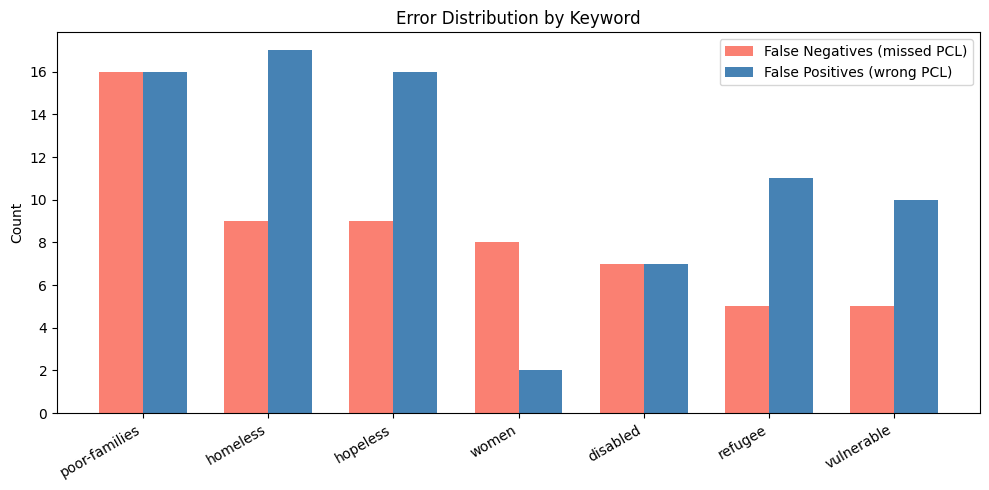

In [13]:
import matplotlib.pyplot as plt
import numpy as np

keywords = ['poor-families', 'homeless', 'hopeless', 'women', 'disabled', 'refugee', 'vulnerable']
fn_counts = [16, 9, 9, 8, 7, 5, 5]
fp_counts = [16, 17, 16, 2, 7, 11, 10]

x = np.arange(len(keywords))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, fn_counts, width, label='False Negatives (missed PCL)', color='salmon')
ax.bar(x + width/2, fp_counts, width, label='False Positives (wrong PCL)', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(keywords, rotation=30, ha='right')
ax.set_ylabel('Count')
ax.set_title('Error Distribution by Keyword')
ax.legend()
plt.tight_layout()
plt.savefig("error_by_keyword.png", dpi=150, bbox_inches='tight')
plt.show()

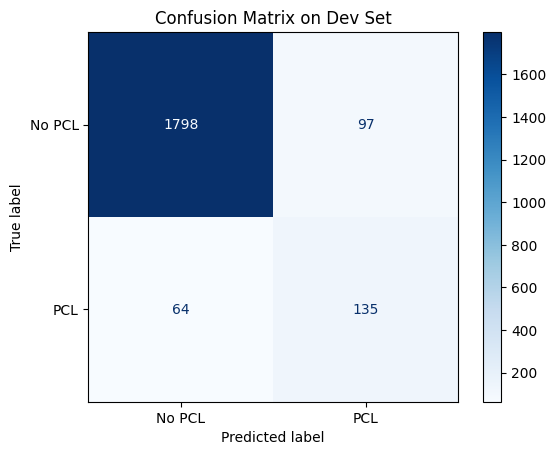

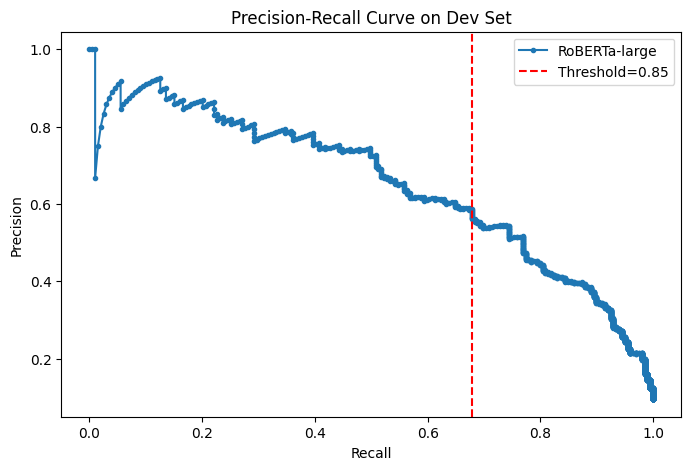

              precision    recall  f1-score   support

      No PCL       0.97      0.95      0.96      1895
         PCL       0.58      0.68      0.63       199

    accuracy                           0.92      2094
   macro avg       0.77      0.81      0.79      2094
weighted avg       0.93      0.92      0.93      2094



In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(dev_labels, dev_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No PCL", "PCL"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Dev Set")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(dev_labels, all_probs)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label='RoBERTa-large')
plt.axvline(x=recall[np.argmin(np.abs(thresholds - threshold))], 
            color='r', linestyle='--', label=f'Threshold={threshold}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve on Dev Set')
plt.legend()
plt.savefig("pr_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print(classification_report(dev_labels, dev_preds, target_names=["No PCL", "PCL"]))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "/home/azureuser/NLP-DETECTING-PCL/BestModel/best_model_checkpoint",
    local_files_only=True
)
model = model.to("cuda")

In [7]:
def get_f1(model, encoded_dataset, threshold=0.85, batch_size=16):
    """Run inference and return best F1 with threshold sweep."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in DataLoader(encoded_dataset, batch_size=batch_size):
            input_ids = batch["input_ids"].to(model.device)
            attention_mask = batch["attention_mask"].to(model.device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    
    labels = encoded_dataset["labels"]
    
    # Sweep thresholds to find best F1
    best_f1, best_thresh = 0, 0.5
    for t in np.arange(0.1, 0.9, 0.01):
        preds = (np.array(all_probs) >= t).astype(int)
        f1 = f1_score(labels, preds)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    
    return best_f1, best_thresh


In [8]:
def encode_dev(df, tokenizer, use_keyword=True, max_length=256):
    """Re-encode dev set with given settings."""
    dataset = Dataset.from_pandas(df[['text', 'binary_label', 'keyword']].reset_index(drop=True))
    
    def tokenize_fn(examples):
        if use_keyword:
            texts = [f"Topic: {k}. {t}" for k, t in zip(examples["keyword"], examples["text"])]
        else:
            texts = [t if isinstance(t, str) else "" for t in examples["text"]]
        return tokenizer(texts, padding="max_length", truncation=True, max_length=max_length)
    
    encoded = dataset.map(tokenize_fn, batched=True)
    encoded = encoded.rename_column("binary_label", "labels")
    encoded = encoded.remove_columns(["keyword", "text"])
    encoded.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return encoded

In [9]:
results = {}

# Full model (baseline for comparison)
print("Running: Full model (keyword + max_length=256)...")
enc = encode_dev(dev_df, tokenizer, use_keyword=True, max_length=256)
f1, thresh = get_f1(model, enc)
results["Full model (keyword + 256)"] = {"f1": f1, "threshold": thresh}
print(f"  F1={f1:.4f}, threshold={thresh:.2f}")

Running: Full model (keyword + max_length=256)...


Map: 100%|██████████| 2094/2094 [00:00<00:00, 8490.84 examples/s]


  F1=0.6265, threshold=0.85


In [10]:
# Without keyword prefix
print("Running: No keyword prefix...")
enc = encode_dev(dev_df, tokenizer, use_keyword=False, max_length=256)
f1, thresh = get_f1(model, enc)
results["No keyword prefix"] = {"f1": f1, "threshold": thresh}
print(f"  F1={f1:.4f}, threshold={thresh:.2f}")

Running: No keyword prefix...


Map: 100%|██████████| 2094/2094 [00:00<00:00, 5039.59 examples/s]


  F1=0.6005, threshold=0.87


In [11]:
# max_length=128
print("Running: max_length=128...")
enc = encode_dev(dev_df, tokenizer, use_keyword=True, max_length=128)
f1, thresh = get_f1(model, enc)
results["max_length=128"] = {"f1": f1, "threshold": thresh}
print(f"  F1={f1:.4f}, threshold={thresh:.2f}")

Running: max_length=128...


Map: 100%|██████████| 2094/2094 [00:00<00:00, 12171.76 examples/s]


  F1=0.6285, threshold=0.83


In [12]:
print("\n ABLATION RESULTS")
print(f"{'Configuration':<35} {'F1':>8} {'Threshold':>10} {'Change vs Full':>15}")
print("-" * 72)
full_f1 = results["Full model (keyword + 256)"]["f1"]
for name, res in results.items():
    delta = res["f1"] - full_f1
    delta_str = f"{delta:+.4f}" if name != "Full model (keyword + 256)" else "—"
    print(f"{name:<35} {res['f1']:>8.4f} {res['threshold']:>10.2f} {delta_str:>15}")


 ABLATION RESULTS
Configuration                             F1  Threshold  Change vs Full
------------------------------------------------------------------------
Full model (keyword + 256)            0.6265       0.85               —
No keyword prefix                     0.6005       0.87         -0.0259
max_length=128                        0.6285       0.83         +0.0020
